# Plotting Regions on NGC 253: Ring

### Importing Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import os
import shutil
from astropy.io import fits # importing fits 
from astropy.utils.data import download_file # simple method of downloading FITS file 
from astropy.visualization import astropy_mpl_style # resource for organized plots
from astropy.visualization import ZScaleInterval, MinMaxInterval, AsinhStretch, LogStretch, ImageNormalize # quality image display/visualization
from astropy.wcs import WCS #coordinate conversion
from regions import Regions # import astropy region class for plotting regions


## A.) Class to Display FITS Image Data and Plot DS9 Regions

In [2]:
class DisplayData: 
    """" A class to open FITS file, display image data, 
         and plot a DS9.reg file onto the image data. """ 
    def __init__(self, filepath):
        """ Initialize through opening the data.""" 
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul: # opening file
            data = None
            header = None
            for hdu in hdul: #loops through each extension (HDU) in the list of HDUs to check if data has dimensions (thanks rav!)
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
       # hdu = fits.open(filepath)[1] #okay index 1 isn't always gong to work. you need to write an if statement to test 0


    def display_header(self, filepath):
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")

    def display_image(self, filepath, norm, vmin, vmax):
        self.filepath = filepath 
        self.norm = norm
        self.vmin = vmin
        self.vmax = vmax
        #brightness control
        #hdu = fits.open(filepath)[1]
        #data = hdu.data
        #header = hdu.header 
        from astropy.io import fits
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")



        plt.figure(figsize=(8, 8))
        plt.imshow(data, cmap="gray", origin="lower", norm=self.norm, vmin=self.vmin, vmax=self.vmax) #figure out a way to add normalization parameter into this function
        plt.colorbar(label="Intensity", fraction=0.0146, aspect=20)
    

    
    def plot_region(self, filepath, regionfile, norm, vmin, vmax):
        self.filepath = filepath
        self.regionfile = regionfile # DS9 region
        self.norm = norm 
        self.vmin = vmin
        self.vmax= vmax 
        from astropy.io import fits 
        from astropy.wcs import WCS
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
            
        wcs = WCS(header) #see https://astronomy.stackexchange.com/questions/51673/how-to-slice-wcs-in-a-fits-file
        region = Regions.read(regionfile)[0].to_pixel(wcs) # access region file via parsing & converting data from wcs to pixel. the 0 is for the FIRST region plotted 
        region2 = Regions.read(regionfile)[1].to_pixel(wcs) # the one corresponds to the SECOND region plotted 
        fig, ax = plt.subplots() 
        ax.imshow(data, cmap='gray', origin='lower', norm=self.norm, vmin=self.vmin, vmax=self.vmax)
        region.plot(ax=ax, color='blue', lw=2.0)
        region2.plot(ax=ax, color='blue', lw=2.0)




        
        

In [ ]:
# loop for plotting multiple regions 
for regions in regionfile

## CO emission: ACA 7m

## HI: Unknown

In [ ]:
No region

## HI: Meerkat

(1002, 1002)


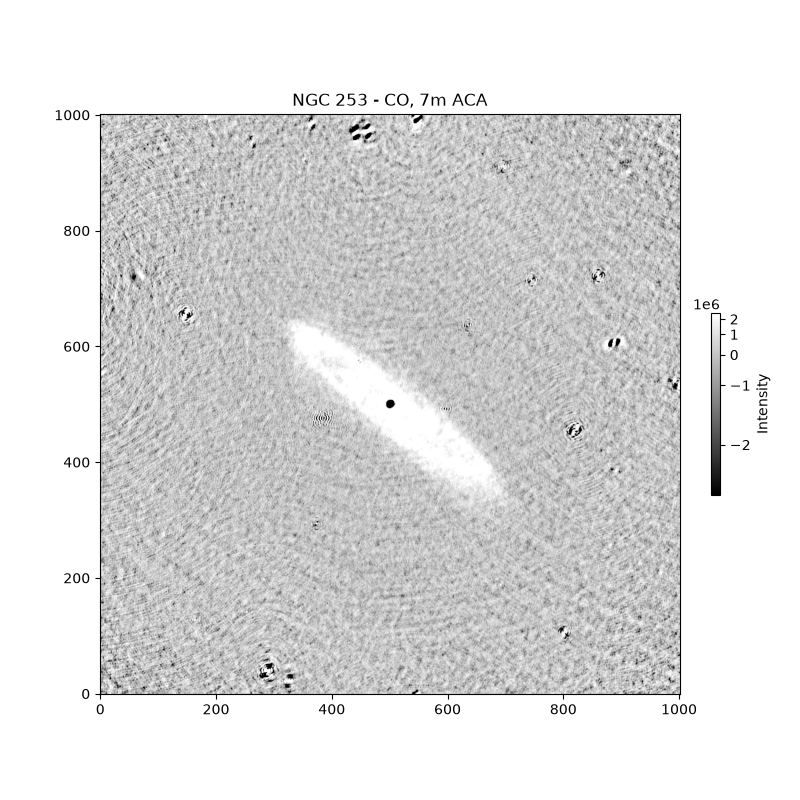

In [28]:
h1m_hdu = fits.open(r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/NGC0253_HI_mosaic_cube_mom0.fits")[0]
h1m_data2D = h1m_hdu.data[0]
print(h1m_data2D.shape)
norm = ImageNormalize(h1m_data2D, 
                         interval=ZScaleInterval(), # changing the scale to zscale and stretching to show emission (works like ds9 settings?)
                          stretch=AsinhStretch())

plt.figure(figsize=(8, 8))
plt.imshow(h1m_data2D, cmap='gray', origin="lower", norm=norm)
plt.colorbar(label="Intensity", fraction=0.0146, aspect=20)
plt.title("NGC 253 - CO, 7m ACA")
plt.show()

## H-alpha: MUSE

Found data in extension: HA6562_FLUX
Found data in extension: HA6562_FLUX


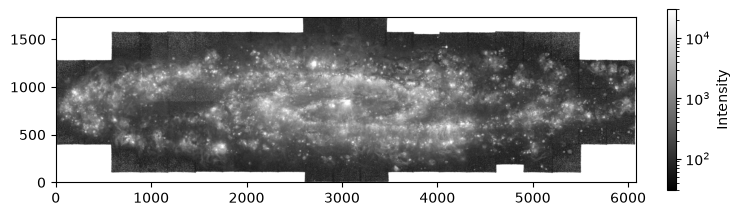

In [3]:
ha_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\NGC0253_Ha.fits"
ha_data = DisplayData(ha_file)
ha_data.display_image(ha_file, 'log', 30, 30000)

Found data in extension: HA6562_FLUX


C:\Users\Lamat\AppData\Local\Programs\Python\Python314\Lib\site-packages\regions\shapes\ellipse.py:222: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Ellipse(xy=xy, width=width, height=height, angle=angle,


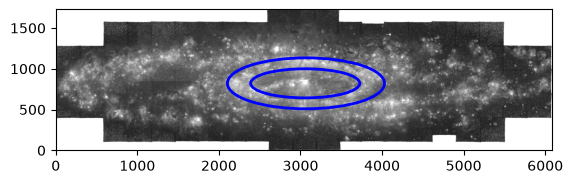

In [4]:
ha_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_ha_regionfile_muse_2.reg"
ha_data.plot_region(ha_file, ha_ring_regionfile, norm = 'log', vmin=30, vmax=30000)

## IRAC4: Spitzer

Found data in extension: PRIMARY
Found data in extension: PRIMARY


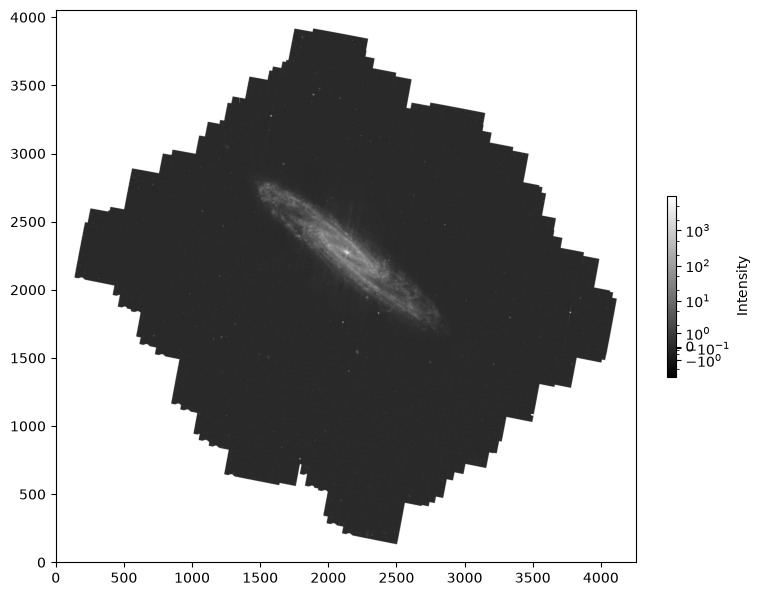

In [24]:
irac4_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\ngc0253_irac4_gauss4p0.fits"
irac4_data = DisplayData(irac4_file)
irac4_data.display_image(irac4_file, 'asinh', None, None)

Found data in extension: PRIMARY


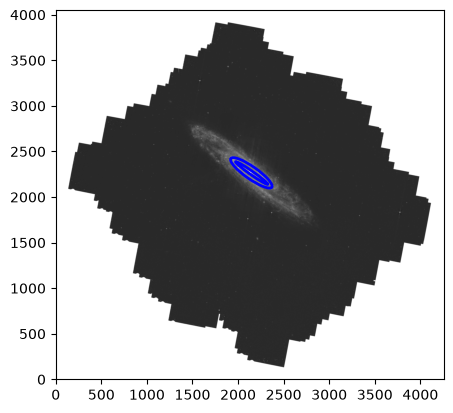

In [26]:
irac4_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_irac_regionfile_spitzer.reg"
irac4_data.plot_region(irac4_file, irac4_ring_regionfile, 'asinh', None, None) #how do I zoom in? 

## IRAC1: Spitzer

In [23]:
irac1_file = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ngc0253_lvl_release_irac1_gauss3.fits"
irac1_data = DisplayData(irac1_file)
irac1_data.display_image(irac1_file, 'asinh', None, None)

Found data in extension: PRIMARY
Found data in extension: PRIMARY


## MIRI f21: JWST

Found data in extension: SCI
Found data in extension: SCI


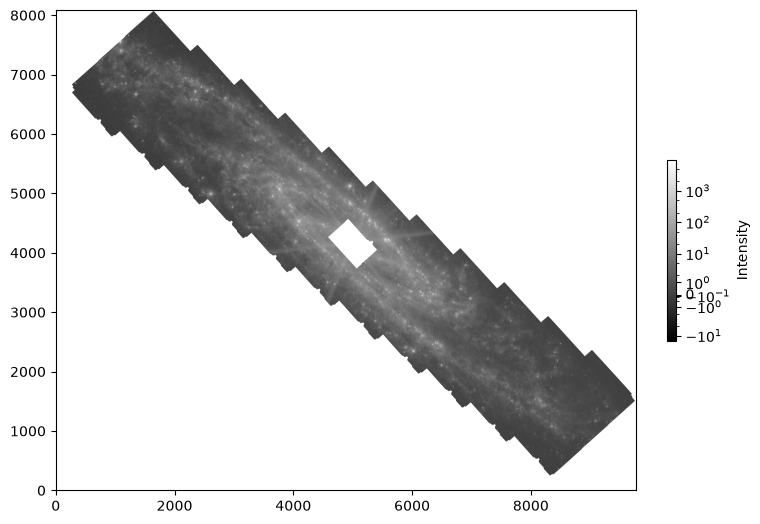

In [10]:
mirif21_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\ngc0253_miri_lv3_f2100w_i2d_align.fits"
mirif21_data = DisplayData(mirif21_file)
mirif21_data.display_image(mirif21_file, 'asinh', None, None)

Found data in extension: SCI


C:\Users\Lamat\AppData\Local\Programs\Python\Python314\Lib\site-packages\regions\shapes\ellipse.py:222: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Ellipse(xy=xy, width=width, height=height, angle=angle,


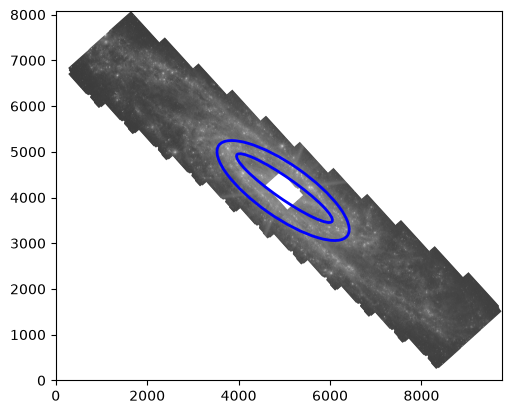

In [11]:
mirif21_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_mirif21_regionfile_jwst_thicker.reg"
mirif21_data.plot_region(mirif21_file, mirif21_ring_regionfile, 'asinh', None, None)

## R-band: WFI

Found data in extension: PRIMARY
Found data in extension: PRIMARY


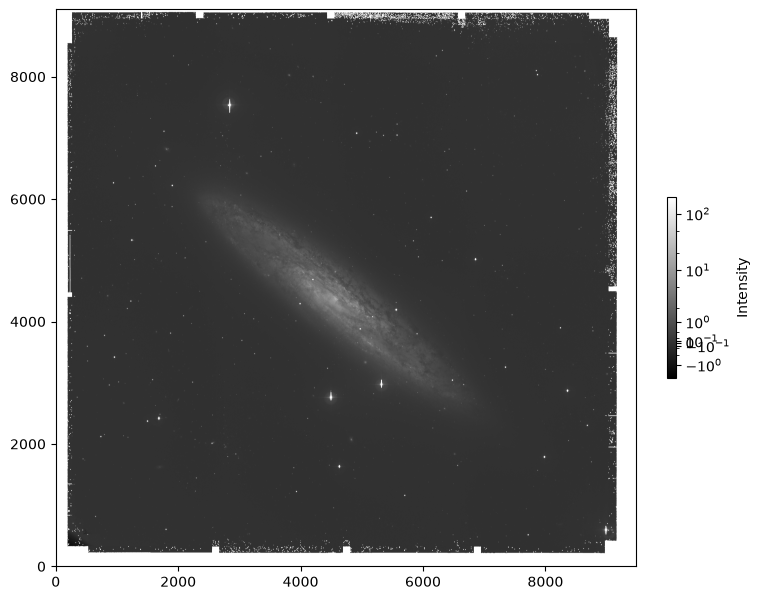

In [14]:
rband_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\NGC0253_Rc_flux_wcomb.fits"
rband_data = DisplayData(rband_file)
rband_data.display_image(rband_file, norm='asinh', vmin=None, vmax=None)

Found data in extension: PRIMARY


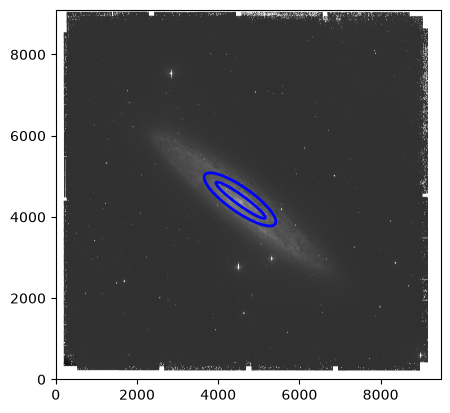

In [16]:
rband_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_rband_regionfile2_wfi.reg"
rband_data.plot_region(rband_file, rband_ring_regionfile, 'asinh', vmin=None, vmax=None)

## UVIS: HST

## V-band: MUSE

Found data in extension: DATA
Found data in extension: DATA


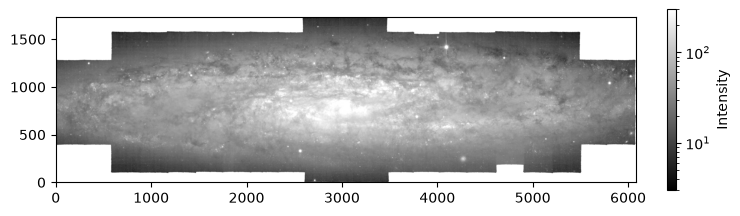

In [12]:
vband_file = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/NGC0253_V.fits"
vband_data = DisplayData(vband_file)
vband_data.display_image(vband_file, 'log', vmin=3, vmax=300)

Found data in extension: DATA


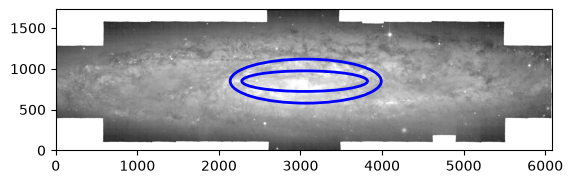

In [14]:
vband_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_vband_regionfile_muse.reg"
vband_data.plot_region(vband_file, vband_ring_regionfile, 'log', vmin=3, vmax=300)

## W1: Wise

Found data in extension: PRIMARY
Found data in extension: PRIMARY


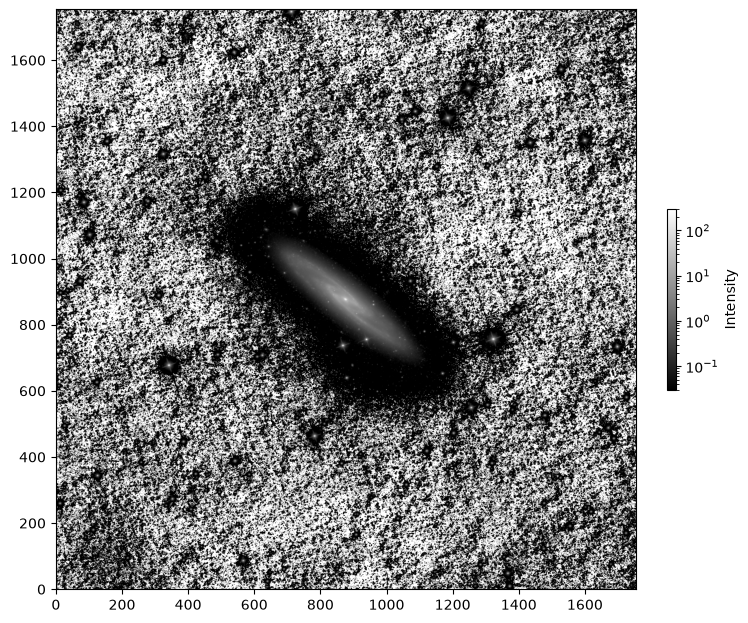

In [18]:
w1_file = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ngc0253_w1_bgsub.fits"
w1_data = DisplayData(w1_file)
w1_data.display_image(w1_file, 'log', vmin=0.03, vmax=300)

In [1]:
%matplotlib widget
w1_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_w1_regionfile_wise.reg"
w1_data.plot_region(w1_file, w1_ring_regionfile, 'log', vmin=3, vmax=300) #this looks horrid, fix in the morning

NameError: name 'w1_data' is not defined